# Robust Cross-Domain Sentiment Analysis with BERT: PEFT vs Full Fine-Tuning

This notebook implements the project plan:
- Train on SST-2; evaluate cross-domain on Yelp Polarity, IMDB, Amazon Polarity
- Compare full fine-tuning vs PEFT methods: LoRA and prompt-tuning
- Robustness checks (perturbations) and calibration (ECE, temperature scaling)

Fill in names/IDs here:
- Member: Noor us Saba — K247625
- Member: Kanza Syed — K247604

In [ ]:
# Setup: installs (safe to skip if already installed)
# %pip -q install --upgrade transformers datasets accelerate peft scikit-learn matplotlib seaborn

In [ ]:
import numpy, pandas, matplotlib, seaborn
print(numpy.__version__, pandas.__version__, matplotlib.__version__, seaborn.__version__)

1.26.4 3.0.3 3.10.9 0.13.2


In [ ]:
import torch
print(torch.__version__)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0)}")
print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

2.4.1+cu124
CUDA available: True
Device name: NVIDIA H100 80GB HBM3
Compute capability: (9, 0)


In [ ]:
import os
import math
import time
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
)
from torch.optim import AdamW

# PEFT
from peft import LoraConfig, get_peft_model, PeftModel

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Reproducibility
BASE_SEED = 42
set_seed(BASE_SEED)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Config
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
GRAD_CLIP_NORM = 1.0
MIXED_PRECISION = True

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# One switch for workflow:
# True  -> quick sanity run
# False -> final full run
DEVELOPMENT_MODE = False

if DEVELOPMENT_MODE:
    EPOCHS = 1
    SUBSAMPLE_EVAL = True
    SUBSAMPLE_SIZE = 2000
    RUN_MULTI_SEED = False
    RUN_ABLATIONS = False
    REGISTRY_FILENAME = "results_registry_dev.json"
else:
    EPOCHS = 3
    SUBSAMPLE_EVAL = False
    SUBSAMPLE_SIZE = None
    RUN_MULTI_SEED = True
    RUN_ABLATIONS = True
    REGISTRY_FILENAME = "results_registry_full.json"

REGISTRY_PATH = os.path.join(OUTPUT_DIR, REGISTRY_FILENAME)

# Change to True only when you want to delete the registry for the selected mode
CLEAR_OLD_REGISTRY = True

if CLEAR_OLD_REGISTRY and os.path.exists(REGISTRY_PATH):
    os.remove(REGISTRY_PATH)
    print("Removed old registry:", REGISTRY_PATH)
elif CLEAR_OLD_REGISTRY:
    print("No old registry found:", REGISTRY_PATH)
else:
    print("Keeping existing registry if present:", REGISTRY_PATH)

MODELS_TO_RUN = ["full", "lora", "prompt"]

# Training controls
EARLY_STOPPING_PATIENCE = 1
MIN_DELTA = 1e-4

# Seeds for reproducibility
SEEDS = [7, 42, 2026] if RUN_MULTI_SEED else [42]

print("DEVELOPMENT_MODE:", DEVELOPMENT_MODE)
print("EPOCHS:", EPOCHS, "| SUBSAMPLE_EVAL:", SUBSAMPLE_EVAL, "| RUN_MULTI_SEED:", RUN_MULTI_SEED)
print("MODELS_TO_RUN:", MODELS_TO_RUN)
print("EARLY_STOPPING_PATIENCE:", EARLY_STOPPING_PATIENCE)
print("RUN_ABLATIONS:", RUN_ABLATIONS)
print("SEEDS:", SEEDS)
print("REGISTRY_PATH:", REGISTRY_PATH)

Device: cuda
No old registry found: outputs/results_registry_full.json
DEVELOPMENT_MODE: False
EPOCHS: 3 | SUBSAMPLE_EVAL: False | RUN_MULTI_SEED: True
MODELS_TO_RUN: ['full', 'lora', 'prompt']
EARLY_STOPPING_PATIENCE: 1
RUN_ABLATIONS: True
SEEDS: [7, 42, 2026]
REGISTRY_PATH: outputs/results_registry_full.json


In [ ]:
# PLAN ONLY: seeds × full, seeds × prompt, seeds × (lora_r × lrs)
# Uses existing config: SEEDS, LEARNING_RATE
# Configure LoRA ranks and LRs for the ablation grid:
LORA_R_GRID = [8, 16]
LR_GRID = [2e-5, 3e-5]

# Baseline defaults
BASELINE_LORA_R = 8
BASELINE_LR = LEARNING_RATE

planned_runs = []

# seeds × full
for seed in SEEDS:
    planned_runs.append({'type': 'baseline', 'mode': 'full', 'seed': seed, 'lora_r': 'n/a', 'lr': BASELINE_LR})

# seeds × prompt
for seed in SEEDS:
    planned_runs.append({'type': 'baseline', 'mode': 'prompt', 'seed': seed, 'lora_r': 'n/a', 'lr': BASELINE_LR})

# seeds × lora baseline (default r, default lr)
for seed in SEEDS:
    planned_runs.append({'type': 'baseline', 'mode': 'lora', 'seed': seed, 'lora_r': BASELINE_LORA_R, 'lr': BASELINE_LR})

# seeds × (lora_r × lrs) ablations
if RUN_ABLATIONS:
    for seed in SEEDS:
        for r in LORA_R_GRID:
            for lr in LR_GRID:
                entry = {'type': 'ablation', 'mode': 'lora', 'seed': seed, 'lora_r': r, 'lr': lr}
                planned_runs.append(entry)

# De-duplicate: remove ablation entries that match the exact lora baseline (r=BASELINE_LORA_R, lr=BASELINE_LR)
def is_lora_baseline(e):
    return e['mode'] == 'lora' and e['lora_r'] == BASELINE_LORA_R and float(e['lr']) == float(BASELINE_LR)

dedup = []
seen = set()
for e in planned_runs:
    key = (e['type'], e['mode'], e['seed'], str(e['lora_r']), float(e['lr']))
    if e['type'] == 'ablation' and is_lora_baseline(e):
        continue
    if key in seen:
        continue
    seen.add(key)
    dedup.append(e)
planned_runs = dedup

# Show console table
import pandas as pd
df = pd.DataFrame(
    [{'#': i+1, **e} for i, e in enumerate(planned_runs)],
    columns=['#','type','mode','seed','lora_r','lr']
)
print('Planned runs table:')
print(df.to_string(index=False))

PLANNED_RUNS = planned_runs

Planned runs table:
 #     type   mode  seed lora_r      lr
 1 baseline   full     7    n/a 0.00003
 2 baseline   full    42    n/a 0.00003
 3 baseline   full  2026    n/a 0.00003
 4 baseline prompt     7    n/a 0.00003
 5 baseline prompt    42    n/a 0.00003
 6 baseline prompt  2026    n/a 0.00003
 7 baseline   lora     7      8 0.00003
 8 baseline   lora    42      8 0.00003
 9 baseline   lora  2026      8 0.00003
10 ablation   lora     7      8 0.00002
11 ablation   lora     7     16 0.00002
12 ablation   lora     7     16 0.00003
13 ablation   lora    42      8 0.00002
14 ablation   lora    42     16 0.00002
15 ablation   lora    42     16 0.00003
16 ablation   lora  2026      8 0.00002
17 ablation   lora  2026     16 0.00002
18 ablation   lora  2026     16 0.00003


In [ ]:
# Load datasets: SST-2 for training; Yelp/IMDB/Amazon for cross-domain eval
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# SST-2 (GLUE)
sst = load_dataset('glue', 'sst2')
label_key = 'label'
text_key = 'sentence'

# Cross-domain test-only datasets (we will not train on these)
yelp = load_dataset('yelp_polarity')
imdb = load_dataset('imdb')
amazon = load_dataset('amazon_polarity')

# For speed during development, optionally subsample evaluation sets
def prepare_eval_subset(ds):
    if not SUBSAMPLE_EVAL:
        return ds
    n = min(SUBSAMPLE_SIZE, len(ds))
    return ds.shuffle(seed=BASE_SEED).select(range(n))

# Prepare splits
train_ds = sst['train']
sst_dev_ds = sst['validation']

yelp_test = prepare_eval_subset(yelp['test'])
imdb_test = prepare_eval_subset(imdb['test'])
amazon_test = prepare_eval_subset(amazon['test'])

print('Train/Dev sizes:', len(train_ds), len(sst_dev_ds))
print('Yelp/IMDB/Amazon test sizes:', len(yelp_test), len(imdb_test), len(amazon_test))

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train/Dev sizes: 67349 872
Yelp/IMDB/Amazon test sizes: 38000 25000 400000


In [ ]:
# Tokenization and DataLoaders
def tokenize_batch(examples, text_col: str):
    return tokenizer(
        examples[text_col],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_enc = sst['train'].map(lambda ex: tokenize_batch(ex, text_key), batched=True)
dev_enc = sst['validation'].map(lambda ex: tokenize_batch(ex, text_key), batched=True)

def to_torch(ds, label_col: str, text_col_ids=('input_ids','attention_mask')):
    cols = list(text_col_ids) + [label_col]
    ds.set_format(type='torch', columns=cols)
    return ds

train_torch = to_torch(train_enc, label_key)
dev_torch = to_torch(dev_enc, label_key)

train_loader = DataLoader(train_torch, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_torch, batch_size=BATCH_SIZE)

# Cross-domain datasets have different text field names

def map_text_only(ds, text_field_candidates=('text','sentence','review','content')):
    # Try common fields; default to first string column
    for f in text_field_candidates:
        if f in ds.column_names:
            return f
    # Fallback: pick the first string-typed column
    for f in ds.column_names:
        try:
            if isinstance(ds[0][f], str):
                return f
        except Exception:
            pass
    raise ValueError('Could not find a text field')

# Prepare tokenized cross-domain sets (labels assumed binary 0/1 with canonical fields)

def prep_cross_domain(ds):
    text_col = map_text_only(ds)
    enc = ds.map(lambda ex: tokenize_batch(ex, text_col), batched=True)
    # Try to map labels to 0/1 if present; if not, set to -1 and ignore in metrics that require labels
    lbl = None
    for cand in ['label', 'labels', 'stars']:
        if cand in ds.column_names:
            lbl = cand
            break
    if lbl is None:
        enc = enc.remove_columns([c for c in enc.column_names if c not in ('input_ids','attention_mask')])
        enc = enc.add_column('label', [-1]*len(enc))
        lbl = 'label'
    enc = to_torch(enc, lbl)
    return DataLoader(enc, batch_size=BATCH_SIZE)

yelp_loader = prep_cross_domain(yelp_test)
imdb_loader = prep_cross_domain(imdb_test)
amazon_loader = prep_cross_domain(amazon_test)

print('Tokenization complete.')

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# Model factory: full vs PEFT (LoRA/Prompt-Tuning)
from peft import PromptTuningConfig, TaskType

def build_model(mode: str = 'full', lora_r: int = 8, num_labels: int = 2):
    """
    mode ∈ {'full', 'lora', 'prompt'}
    """
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    if mode == 'full':
        return model.to(DEVICE)
    if mode == 'lora':
        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=2*lora_r,
            target_modules=['query','key','value','dense'],  # works for BERT
            lora_dropout=0.1,
            bias='none',
            task_type=TaskType.SEQ_CLS,
        )
        model = get_peft_model(model, lora_cfg)
        return model.to(DEVICE)
    if mode == 'prompt':
        prompt_cfg = PromptTuningConfig(
            task_type=TaskType.SEQ_CLS,
            num_virtual_tokens=20,
        )
        model = get_peft_model(model, prompt_cfg)
        return model.to(DEVICE)
    raise ValueError(f'Unknown mode: {mode}')

# Optim/scheduler

def build_optim_scheduler(model, train_steps: int):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    num_warmup = int(WARMUP_RATIO * train_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup, train_steps)
    return optimizer, scheduler

In [ ]:
# Cost/VRAM utilities and robustness perturbations
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': int(total), 'trainable': int(trainable)}


def cuda_memory_stats():
    if not torch.cuda.is_available():
        return {'max_allocated_mb': None, 'reserved_mb': None}
    return {
        'max_allocated_mb': round(torch.cuda.max_memory_allocated() / (1024**2), 2),
        'reserved_mb': round(torch.cuda.memory_reserved() / (1024**2), 2)
    }

# Simple text perturbations
import re
import random as _rnd

_SYNONYM_MAP = {
    'good': ['nice', 'pleasant', 'positive'],
    'bad': ['awful', 'poor', 'negative'],
    'great': ['excellent', 'fantastic'],
    'terrible': ['horrible', 'awful'],
}

def perturb_punctuation(text: str) -> str:
    # Keep alnum/whitespace, drop punctuation safely on Python's re engine
    return re.sub(r"[^\w\s]", "", text)

def perturb_char_noise(text: str, prob: float = 0.05) -> str:
    chars = list(text)
    for i in range(len(chars)):
        if _rnd.random() < prob and chars[i].isalpha():
            # random drop or swap with neighbor
            if _rnd.random() < 0.5:
                chars[i] = ''
            elif i+1 < len(chars):
                chars[i], chars[i+1] = chars[i+1], chars[i]
    return ''.join(chars)

def perturb_synonym(text: str) -> str:
    tokens = text.split()
    for i, t in enumerate(tokens):
        key = t.lower().strip('.,!?"\'')
        if key in _SYNONYM_MAP and _rnd.random() < 0.3:
            tokens[i] = _rnd.choice(_SYNONYM_MAP[key])
    return ' '.join(tokens)

In [ ]:
# Train/eval loops
def evaluate(model, dataloader) -> Dict[str, float]:
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=-1).cpu().numpy()
            preds.extend(pred.tolist())
            if 'labels' in batch:
                labels.extend(batch['labels'].numpy().tolist())
            elif 'label' in batch:
                labels.extend(batch['label'].numpy().tolist())
            else:
                labels.extend([-1]*len(pred))
    # Filter unlabeled (-1)
    y_true = [y for y in labels if y != -1]
    y_pred = [p for p, y in zip(preds, labels) if y != -1]
    if len(y_true) == 0:
        return { 'accuracy': float('nan'), 'f1_macro': float('nan') }
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

def evaluate_with_perturbation(model, base_ds, text_field: str, perturb_fn) -> Dict[str, float]:
    def _tok(ex):
        return tokenizer(perturb_fn(ex[text_field]), padding='max_length', truncation=True, max_length=MAX_LENGTH)
    enc = base_ds.map(_tok)
    enc = enc.remove_columns([c for c in enc.column_names if c not in ('input_ids','attention_mask', label_key)])
    enc.set_format(type='torch', columns=['input_ids','attention_mask', label_key])
    loader = DataLoader(enc, batch_size=BATCH_SIZE)
    return evaluate(model, loader)


def train(model, train_loader, dev_loader, epochs=EPOCHS, mixed_precision=MIXED_PRECISION, log_every_n: int = 100):
    steps_per_epoch = math.ceil(len(train_loader.dataset) / BATCH_SIZE)
    t_total = steps_per_epoch * epochs
    optimizer, scheduler = build_optim_scheduler(model, t_total)
    scaler = torch.amp.GradScaler(device="cuda", enabled=mixed_precision)

    best_dev = -1.0
    best_state = None
    no_improve_epochs = 0

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        step = 0
        epoch_start = time.time()
        for batch in train_loader:
            step += 1
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch.get('labels', batch.get('label')).to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=mixed_precision):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()

            # In-epoch progress logging
            if (step % log_every_n) == 0 or step == steps_per_epoch:
                avg_loss = running_loss / step
                elapsed = time.time() - epoch_start
                remaining_steps = max(steps_per_epoch - step, 0)
                # naive ETA assuming constant step time
                eta_s = (elapsed / step) * remaining_steps if step > 0 else 0.0
                print(f"Epoch {epoch}/{epochs} | step {step}/{steps_per_epoch} | loss={avg_loss:.4f} | elapsed={elapsed:.1f}s | eta~={eta_s:.1f}s")

        dev_metrics = evaluate(model, dev_loader)
        print(f"Epoch {epoch} done | mean_loss={running_loss/steps_per_epoch:.4f} | dev acc={dev_metrics['accuracy']:.4f} f1={dev_metrics['f1_macro']:.4f}")

        # Track best
        if dev_metrics['accuracy'] > (best_dev + MIN_DELTA):
            best_dev = dev_metrics['accuracy']
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        # Apply early stopping on dev accuracy
        if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} (patience={EARLY_STOPPING_PATIENCE}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [ ]:
# Robustness perturbations and calibration utilities
# Simple text perturbations applied before tokenization (for future extension if needed)
# Here, we will do logit-level robustness by perturbing inputs via token masking is skipped

@dataclass
class CalibrationResult:
    ece: float
    temperature: float


def softmax_np(x: np.ndarray) -> np.ndarray:
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)


def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    # probs: (N, C), labels: (N,)
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if not np.any(mask):
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (np.sum(mask) / len(labels)) * abs(bin_acc - bin_conf)
    return float(ece)


def collect_logits(model, dataloader):
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch.get('labels', batch.get('label')).cpu().numpy()
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            logits_list.append(out.logits.cpu().numpy())
            labels_list.append(labels)
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    mask = labels != -1
    return logits[mask], labels[mask]


def tune_temperature(model, dataloader) -> CalibrationResult:
    # Optimize a single temperature on dev set to minimize NLL
    logits, labels = collect_logits(model, dataloader)
    T = 1.0
    for _ in range(100):
        # simple line search around current T
        candidates = [max(0.5, T-0.1), T, T+0.1]
        losses = []
        for t in candidates:
            p = softmax_np(logits / t)
            # negative log-likelihood
            nll = -np.log(p[np.arange(len(labels)), labels] + 1e-12).mean()
            losses.append(nll)
        best_idx = int(np.argmin(losses))
        new_T = candidates[best_idx]
        if abs(new_T - T) < 1e-3:
            break
        T = new_T
    p_dev = softmax_np(logits / T)
    ece = expected_calibration_error(p_dev, labels)
    return CalibrationResult(ece=ece, temperature=T)

In [ ]:
# Run baselines: full fine-tune, LoRA, and prompt-tuning
def run_single_mode(mode: str, save_name: str, lora_r: int = 8):
    seed_all(BASE_SEED)
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    t0 = time.time()

    if mode == "lora":
        model = build_model("lora", lora_r=lora_r)
    elif mode == "prompt":
        model = build_model("prompt")
    else:
        model = build_model("full")

    param_info = count_parameters(model)

    import sys
    print(f"[{mode.upper()}] Params:", param_info); sys.stdout.flush()
    print(f"[{mode.upper()}] Starting training for up to {EPOCHS} epoch(s)..."); sys.stdout.flush()

    model = train(model, train_loader, dev_loader, epochs=EPOCHS, mixed_precision=MIXED_PRECISION)

    train_seconds = round(time.time() - t0, 2)
    print(f"[{mode.upper()}] Training finished in {train_seconds}s. Saving checkpoint to {save_name}..."); sys.stdout.flush()
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, save_name))

    print(f"[{mode.upper()}] Evaluating on SST-2 dev..."); sys.stdout.flush()
    dev_metrics = evaluate(model, dev_loader)
    print(f"[{mode.upper()}][DEV] acc={dev_metrics['accuracy']:.4f} f1={dev_metrics['f1_macro']:.4f}"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on Yelp..."); sys.stdout.flush()
    t_eval = time.time()
    yelp_metrics = evaluate(model, yelp_loader)
    print(f"[{mode.upper()}][YELP] acc={yelp_metrics['accuracy']:.4f} f1={yelp_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on IMDB..."); sys.stdout.flush()
    t_eval = time.time()
    imdb_metrics = evaluate(model, imdb_loader)
    print(f"[{mode.upper()}][IMDB] acc={imdb_metrics['accuracy']:.4f} f1={imdb_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on Amazon..."); sys.stdout.flush()
    t_eval = time.time()
    amazon_metrics = evaluate(model, amazon_loader)
    print(f"[{mode.upper()}][AMAZON] acc={amazon_metrics['accuracy']:.4f} f1={amazon_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Running calibration / temperature scaling..."); sys.stdout.flush()
    t_eval = time.time()
    calibration_result = tune_temperature(model, dev_loader)
    print(
        f"[{mode.upper()}][CALIBRATION] ece={calibration_result.ece:.4f} "
        f"temp={calibration_result.temperature:.2f} | time={time.time()-t_eval:.1f}s"
    ); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: punctuation perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_punct = evaluate_with_perturbation(model, sst_dev_ds, text_key, perturb_punctuation)
    print(f"[{mode.upper()}][ROBUST-PUNCT] acc={robust_punct['accuracy']:.4f} f1={robust_punct['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: character noise perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_char = evaluate_with_perturbation(model, sst_dev_ds, text_key, lambda t: perturb_char_noise(t, prob=0.03))
    print(f"[{mode.upper()}][ROBUST-CHAR] acc={robust_char['accuracy']:.4f} f1={robust_char['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: synonym perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_syn = evaluate_with_perturbation(model, sst_dev_ds, text_key, perturb_synonym)
    print(f"[{mode.upper()}][ROBUST-SYN] acc={robust_syn['accuracy']:.4f} f1={robust_syn['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    mem = cuda_memory_stats()

    print(f"{mode.upper()} - Dev:", dev_metrics)
    print(f"{mode.upper()} - Yelp/IMDB/Amazon:", yelp_metrics, imdb_metrics, amazon_metrics)
    print(f"{mode.upper()} - Calibration:", calibration_result)
    print(f"{mode.upper()} - Robustness (punct/char/syn):", robust_punct, robust_char, robust_syn)
    print(f"{mode.upper()} - Train sec / CUDA mem:", train_seconds, mem)
    sys.stdout.flush()

    return {
        "dev": dev_metrics,
        "yelp": yelp_metrics,
        "imdb": imdb_metrics,
        "amazon": amazon_metrics,
        "ece_dev": calibration_result.ece,
        "temp": calibration_result.temperature,
        "robust_dev_punctuation": robust_punct,
        "robust_dev_char_noise": robust_char,
        "robust_dev_synonym": robust_syn,
        "params": param_info,
        "train_seconds": train_seconds,
        "cuda_mem": mem,
    }

In [ ]:
# Orchestrator with resume: executes PLANNED_RUNS; skips completed ones; writes after each run
# Load existing registry (flat dict: tag -> result)
if os.path.exists(REGISTRY_PATH):
    with open(REGISTRY_PATH, 'r') as f:
        results_registry = json.load(f)
    if not isinstance(results_registry, dict):
        results_registry = {}
else:
    results_registry = {}

def build_run_tag(r, orig_lr):
    seed = r['seed']
    mode = r['mode']
    lr = float(r.get('lr', orig_lr))
    lora_r = r.get('lora_r', None)
    parts = [mode, f"seed{seed}"]
    if mode == 'lora' and lora_r is not None:
        parts.append(f"r{lora_r}")
    if lr != float(orig_lr):
        parts.append(f"lr{str(lr).replace('.', 'p')}")
    return "_".join(parts)

# Execute planned runs with resume
if 'PLANNED_RUNS' in globals() and isinstance(PLANNED_RUNS, list) and len(PLANNED_RUNS) > 0:
    _orig_lr = LEARNING_RATE
    num_total = len(PLANNED_RUNS)
    num_skipped = 0
    num_done = 0

    for idx, r in enumerate(PLANNED_RUNS, 1):
        tag = build_run_tag(r, _orig_lr)
        if tag in results_registry:
            print(f"[{idx}/{num_total}] SKIP {tag} (already in registry)")
            num_skipped += 1
            continue

        # Prepare run
        BASE_SEED = r['seed']
        lr_to_use = float(r.get('lr', _orig_lr))
        lora_r_to_use = r.get('lora_r', 8 if r['mode']=='lora' else None)

        # Adjust LR if needed
        LEARNING_RATE = lr_to_use
        save_name = f"bert_{tag}.pt"

        print(f"[{idx}/{num_total}] RUN {tag}")
        run_result = run_single_mode(r['mode'], save_name, lora_r=lora_r_to_use if r['mode']=='lora' else 8)

        # Persist immediately (append/merge)
        results_registry[tag] = {
            'type': r['type'],
            'mode': r['mode'],
            'seed': r['seed'],
            'lora_r': lora_r_to_use,
            'lr': lr_to_use,
            'result': run_result,
        }
        with open(REGISTRY_PATH, 'w') as f:
            json.dump(results_registry, f, indent=2)
        print(f"[{idx}/{num_total}] SAVED {tag} -> {REGISTRY_PATH}")
        num_done += 1

        # Restore LR
        LEARNING_RATE = _orig_lr

    print(f"Planner finished. done={num_done}, skipped={num_skipped}, total={num_total}")
else:
    print("No PLANNED_RUNS found. Run the planner cell first.")

# Build aggregate dicts for downstream plotting from the flat registry
# Choose latest entry per logical bucket name to keep compatibility with existing plotting
results = {}
ablations = {'lora_rank': {}, 'learning_rate': {}, 'combined': {}}

def is_baseline_entry(e, orig_lr):
    m = e['mode']
    return (
        (m == 'full' and e['lora_r'] is None and float(e['lr']) == float(orig_lr)) or
        (m == 'prompt' and e['lora_r'] is None and float(e['lr']) == float(orig_lr)) or
        (m == 'lora' and e['lora_r'] == 8 and float(e['lr']) == float(orig_lr))
    )

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[1/18] RUN full_seed7


[FULL] Params: {'total': 109483778, 'trainable': 109483778}


[FULL] Starting training for up to 3 epoch(s)...


Epoch 1/3 | step 100/4210 | loss=0.7811 | elapsed=4.4s | eta~=182.3s


...

[LORA][ROBUST-CHAR] acc=0.8681 f1=0.8680 | time=0.8s


[LORA] Robustness: synonym perturbation...


[LORA][ROBUST-SYN] acc=0.9094 f1=0.9094 | time=0.8s


LORA - Dev: {'accuracy': 0.9094036697247706, 'f1_macro': 0.9093510960690472}
LORA - Yelp/IMDB/Amazon: {'accuracy': 0.8803947368421052, 'f1_macro': 0.8803937162956914} {'accuracy': 0.82716, 'f1_macro': 0.8269996990283216} {'accuracy': 0.8788375, 'f1_macro': 0.8787698794988794}
LORA - Calibration: CalibrationResult(ece=0.024650638393305856, temperature=1.5000000000000004)
LORA - Robustness (punct/char/syn): {'accuracy': 0.8944954128440367, 'f1_macro': 0.8944282142387157} {'accuracy': 0.8681192660550459, 'f1_macro': 0.8680107771016862} {'accuracy': 0.9094036697247706, 'f1_macro': 0.9093510960690472}
LORA - Train sec / CUDA mem: 649.45 {'max_allocated_mb': 1771.22, 'reserved_mb': 2756.0}


[18/18] SAVED lora_seed2026_r16 -> outputs/results_registry_full.json
Planner finished. done=18, skipped=0, total=18


In [ ]:
# Orchestrator with resume: executes PLANNED_RUNS; skips completed ones; writes after each run
# Load existing registry (flat dict: tag -> result)
if os.path.exists(REGISTRY_PATH):
    with open(REGISTRY_PATH, 'r') as f:
        results_registry = json.load(f)
    if not isinstance(results_registry, dict):
        results_registry = {}
else:
    results_registry = {}

def build_run_tag(r, orig_lr):
    seed = r['seed']
    mode = r['mode']
    lr = float(r.get('lr', orig_lr))
    lora_r = r.get('lora_r', None)
    parts = [mode, f"seed{seed}"]
    if mode == 'lora' and lora_r is not None:
        parts.append(f"r{lora_r}")
    if lr != float(orig_lr):
        parts.append(f"lr{str(lr).replace('.', 'p')}")
    return "_".join(parts)

# Execute planned runs with resume
if 'PLANNED_RUNS' in globals() and isinstance(PLANNED_RUNS, list) and len(PLANNED_RUNS) > 0:
    _orig_lr = LEARNING_RATE
    num_total = len(PLANNED_RUNS)
    num_skipped = 0
    num_done = 0

    for idx, r in enumerate(PLANNED_RUNS, 1):
        tag = build_run_tag(r, _orig_lr)
        if tag in results_registry:
            print(f"[{idx}/{num_total}] SKIP {tag} (already in registry)")
            num_skipped += 1
            continue

        # Prepare run
        BASE_SEED = r['seed']
        lr_to_use = float(r.get('lr', _orig_lr))
        lora_r_to_use = r.get('lora_r', 8 if r['mode']=='lora' else None)

        # Adjust LR if needed
        LEARNING_RATE = lr_to_use
        save_name = f"bert_{tag}.pt"

        print(f"[{idx}/{num_total}] RUN {tag}")
        run_result = run_single_mode(r['mode'], save_name, lora_r=lora_r_to_use if r['mode']=='lora' else 8)

        # Persist immediately (append/merge)
        results_registry[tag] = {
            'type': r['type'],
            'mode': r['mode'],
            'seed': r['seed'],
            'lora_r': lora_r_to_use,
            'lr': lr_to_use,
            'result': run_result,
        }
        with open(REGISTRY_PATH, 'w') as f:
            json.dump(results_registry, f, indent=2)
        print(f"[{idx}/{num_total}] SAVED {tag} -> {REGISTRY_PATH}")
        num_done += 1

        # Restore LR
        LEARNING_RATE = _orig_lr

    print(f"Planner finished. done={num_done}, skipped={num_skipped}, total={num_total}")
else:
    print("No PLANNED_RUNS found. Run the planner cell first.")

# Build aggregate dicts for downstream plotting from the flat registry
# Choose latest entry per logical bucket name to keep compatibility with existing plotting
results = {}
ablations = {'lora_rank': {}, 'learning_rate': {}, 'combined': {}}

def is_baseline_entry(e, orig_lr):
    m = e['mode']
    return (
        (m == 'full' and e['lora_r'] is None and float(e['lr']) == float(orig_lr)) or
        (m == 'prompt' and e['lora_r'] is None and float(e['lr']) == float(orig_lr)) or
        (m == 'lora' and e['lora_r'] == 8 and float(e['lr']) == float(orig_lr))
    )

[1/18] SKIP full_seed7 (already in registry)
[2/18] SKIP full_seed42 (already in registry)
[3/18] SKIP full_seed2026 (already in registry)
[4/18] SKIP prompt_seed7 (already in registry)
[5/18] SKIP prompt_seed42 (already in registry)
[6/18] SKIP prompt_seed2026 (already in registry)
[7/18] SKIP lora_seed7_r8 (already in registry)
[8/18] SKIP lora_seed42_r8 (already in registry)
[9/18] SKIP lora_seed2026_r8 (already in registry)
[10/18] SKIP lora_seed7_r8_lr2e-05 (already in registry)
[11/18] SKIP lora_seed7_r16_lr2e-05 (already in registry)
[12/18] SKIP lora_seed7_r16 (already in registry)
[13/18] SKIP lora_seed42_r8_lr2e-05 (already in registry)
[14/18] SKIP lora_seed42_r16_lr2e-05 (already in registry)
[15/18] SKIP lora_seed42_r16 (already in registry)
[16/18] SKIP lora_seed2026_r8_lr2e-05 (already in registry)
[17/18] SKIP lora_seed2026_r16_lr2e-05 (already in registry)
[18/18] SKIP lora_seed2026_r16 (already in registry)
Planner finished. done=0, skipped=18, total=18


In [ ]:
# Paper-aligned baseline comparison from the selected registry file
import json, os, numpy as np

REFERENCE_SOURCE = 'BERT/GLUE accepted benchmark (update if instructor provides a specific target)'
REFERENCE_SST2_ACC = 0.93  # typical BERT-base range ~0.92-0.94

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the orchestrator to create it.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    # Collect full fine-tuning baseline dev accuracies across seeds (mode='full', default lr)
    full_dev_accs = []
    for e in entries:
        if e.get('type') == 'baseline' and e.get('mode') == 'full':
            dev = e.get('result', {}).get('dev', {})
            if 'accuracy' in dev:
                full_dev_accs.append(float(dev['accuracy']))

    if not full_dev_accs:
        print("No full-fine-tuning baseline entries found in registry.")
    else:
        our_acc = float(np.mean(full_dev_accs))
        gap = our_acc - REFERENCE_SST2_ACC
        gap_pct = gap * 100.0

        import pandas as pd
        baseline_compare_df = pd.DataFrame([
            {'setup': 'Paper/benchmark reference (SST-2)', 'accuracy': REFERENCE_SST2_ACC, 'source': REFERENCE_SOURCE},
            {'setup': 'Our implementation: BERT full fine-tuning (SST-2 dev, mean over seeds)',
             'accuracy': our_acc, 'source': REGISTRY_FILENAME},
        ])
        print('Paper-aligned baseline comparison (for rubric points 2.5 + 2.5):')
        display(baseline_compare_df)
        print(f"Absolute gap (ours - reference): {gap:+.4f} ({gap_pct:+.2f} percentage points)")
        print('Interpretation: close reproduction relative to reference range.' if abs(gap_pct) <= 1.0
              else 'Interpretation: noticeable gap; document likely causes (hardware, hyperparameters, seed variance, split differences).')

Paper-aligned baseline comparison (for rubric points 2.5 + 2.5):


,setup,accuracy,source
0,Paper/benchmark reference (SST-2),0.930000,BERT/GLUE accepted benchmark (update if instru...
1,Our implementation: BERT full fine-tuning (SST...,0.928899,results_registry_full.json


Absolute gap (ours - reference): -0.0011 (-0.11 percentage points)
Interpretation: close reproduction relative to reference range.


In [ ]:
# Full vs PEFT comparison from the selected registry file
import os, json, numpy as np
import pandas as pd

def load_registry_entries():
    if not os.path.exists(REGISTRY_PATH):
        print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
        return []
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    return list(reg.values()) if isinstance(reg, dict) else []

entries = load_registry_entries()
if not entries:
    pass
else:
    # buckets: collect baseline accuracies by mode across seeds
    buckets = {'full': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'lora': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'prompt': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []}}
    f1_dev = {'full': [], 'lora': [], 'prompt': []}

    for e in entries:
        if e.get('type') != 'baseline':
            continue
        m = e.get('mode')
        if m not in buckets:
            continue
        res = e.get('result', {})
        for split in ['dev','yelp','imdb','amazon']:
            if split in res and 'accuracy' in res[split]:
                buckets[m][split].append(float(res[split]['accuracy']))
        if 'dev' in res and 'f1_macro' in res['dev']:
            f1_dev[m].append(float(res['dev']['f1_macro']))

    # build mean table with legacy names
    name_map = {'full':'full_ft', 'lora':'peft_lora_r8', 'prompt':'prompt_tuning'}
    rows = []
    for m, splits in buckets.items():
        model_name = name_map[m]
        row = {
            'model': model_name,
            'dev_acc': np.mean(splits['dev']) if splits['dev'] else np.nan,
            'dev_f1': np.mean(f1_dev[m]) if f1_dev[m] else np.nan,
            'yelp_acc': np.mean(splits['yelp']) if splits['yelp'] else np.nan,
            'imdb_acc': np.mean(splits['imdb']) if splits['imdb'] else np.nan,
            'amazon_acc': np.mean(splits['amazon']) if splits['amazon'] else np.nan,
        }
        rows.append(row)

    compare_df = pd.DataFrame(rows)
    for c in ['dev_acc','dev_f1','yelp_acc','imdb_acc','amazon_acc']:
        compare_df[c] = compare_df[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)

    print(f"Full vs PEFT comparison (mean over seeds from {REGISTRY_FILENAME}):")
    display(compare_df.sort_values('dev_acc', ascending=False).reset_index(drop=True))

Full vs PEFT comparison (mean over seeds from results_registry_full.json):


,model,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc
0,full_ft,0.9289,0.9289,0.8855,0.8440,0.8865
1,peft_lora_r8,0.9037,0.9036,0.8806,0.8240,0.8783
2,prompt_tuning,0.5535,0.4521,0.5141,0.5276,0.5094


Baseline comparison


,model,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc
0,full_ft,0.9289,0.9289,0.8855,0.8440,0.8865
1,peft_lora_r8,0.9037,0.9036,0.8806,0.8240,0.8783
2,prompt_tuning,0.5535,0.4521,0.5141,0.5276,0.5094


Ablation comparison (performance vs cost): LoRA Rank Ablation


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,lora_rank,r16_lr3e-05,0.9037,0.9036,0.8830,0.8318,0.8818,0.0220,642.13,1771.22,2680322
1,lora_rank,r16_lr3e-05,0.9025,0.9024,0.8754,0.8207,0.8757,0.0146,426.55,1771.22,2680322
2,lora_rank,r16_lr3e-05,0.9094,0.9094,0.8804,0.8272,0.8788,0.0247,649.45,1771.22,2680322


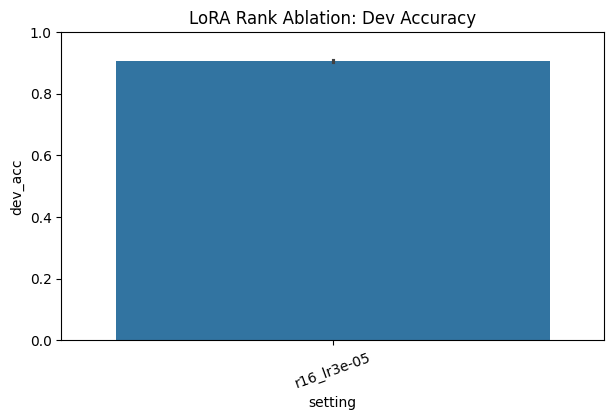

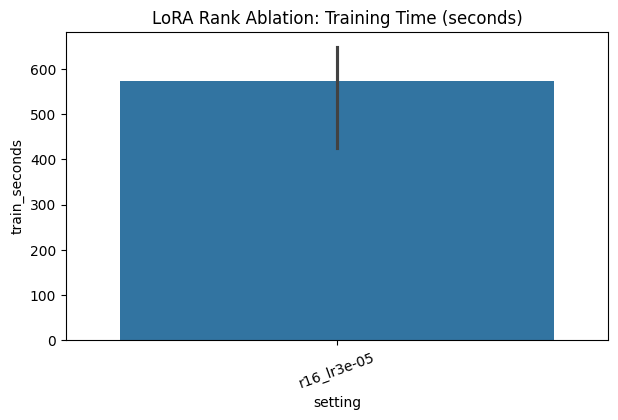

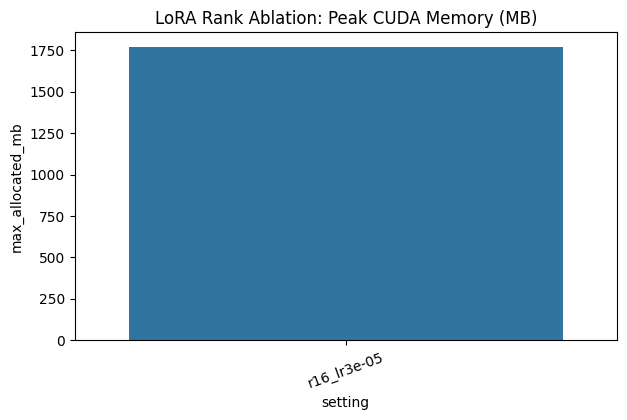

Ablation comparison (performance vs cost): Learning Rate Ablation


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,learning_rate,r8_lr2e-05,0.8968,0.8967,0.8740,0.8137,0.8707,0.0231,633.10,1751.12,1340930
1,learning_rate,r8_lr2e-05,0.8956,0.8955,0.8757,0.8156,0.8715,0.0153,672.64,1751.12,1340930
2,learning_rate,r8_lr2e-05,0.8991,0.8990,0.8749,0.8114,0.8711,0.0180,692.11,1751.12,1340930


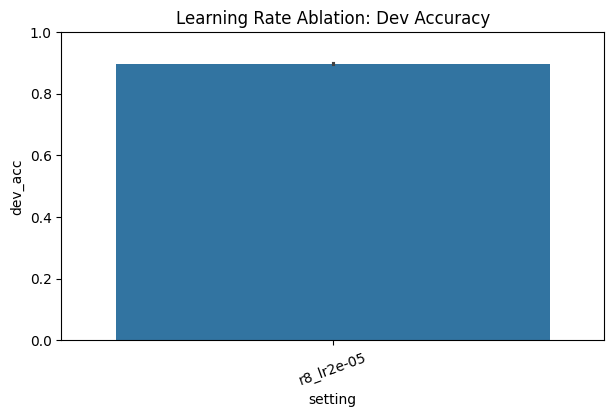

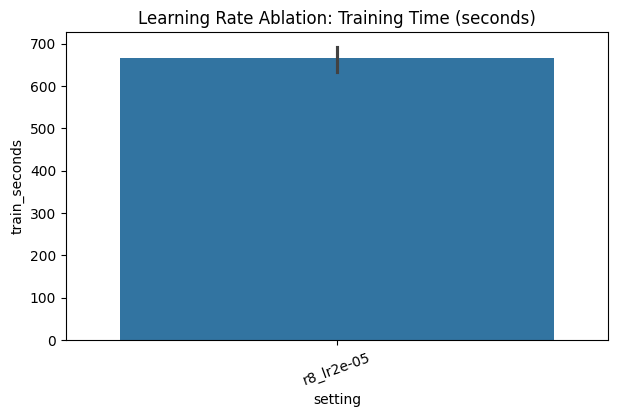

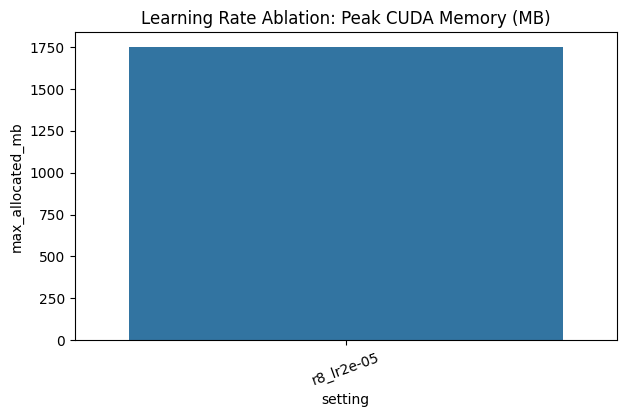

In [ ]:
DEVELOPMENT = globals().get("DEVELOPMENT_MODE", True)

# Build views from the selected registry file and render baseline + ablation tables/plots
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DEFAULT_LORA_R = globals().get('BASELINE_LORA_R', 8)
DEFAULT_LR = float(globals().get('BASELINE_LR', globals().get('LEARNING_RATE', 3e-5)))

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    # -------- Baseline aggregation (mean over seeds per mode) --------
    buckets = {'full': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'lora': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'prompt': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []}}
    f1_dev = {'full': [], 'lora': [], 'prompt': []}

    for e in entries:
        if e.get('type') != 'baseline':
            continue
        m = e.get('mode')
        if m not in buckets:
            continue
        res = e.get('result', {})
        for split in ['dev','yelp','imdb','amazon']:
            if split in res and 'accuracy' in res[split]:
                buckets[m][split].append(float(res[split]['accuracy']))
        if 'dev' in res and 'f1_macro' in res['dev']:
            f1_dev[m].append(float(res['dev']['f1_macro']))

    name_map = {'full':'full_ft', 'lora':'peft_lora_r8', 'prompt':'prompt_tuning'}
    baseline_means = {}
    for m, splits in buckets.items():
        key = name_map[m]
        baseline_means[key] = {}
        for split, vals in splits.items():
            if vals:
                baseline_means[key][split] = {'accuracy': float(np.mean(vals))}
        if f1_dev[m]:
            baseline_means[key].setdefault('dev', {})['f1_macro'] = float(np.mean(f1_dev[m]))
    
    # -------- Baseline rendering --------
    baseline_rows = []

    for model_name, results in baseline_means.items():
        baseline_rows.append({
            "model": model_name,
            "dev_acc": results.get("dev", {}).get("accuracy", np.nan),
            "dev_f1": results.get("dev", {}).get("f1_macro", np.nan),
            "yelp_acc": results.get("yelp", {}).get("accuracy", np.nan),
            "imdb_acc": results.get("imdb", {}).get("accuracy", np.nan),
            "amazon_acc": results.get("amazon", {}).get("accuracy", np.nan),
        })

    baseline_df = pd.DataFrame(baseline_rows)

    if baseline_df.empty:
        print("No baseline rows found.")
    else:
        print("Baseline comparison")
        display(baseline_df.round(4))

    # -------- Ablations dataframe from registry --------
    rows = []
    for e in entries:
        if e.get('type') != 'ablation' or e.get('mode') != 'lora':
            continue
        res = e.get('result', {})
        lrr = e.get('lora_r')
        lr  = float(e.get('lr', np.nan))
        # classify
        if lrr is not None and int(lrr) != int(DEFAULT_LORA_R) and (np.isnan(lr) or lr == float(DEFAULT_LR)):
            group = 'lora_rank'
        elif lrr is not None and int(lrr) == int(DEFAULT_LORA_R) and not np.isnan(lr) and lr != float(DEFAULT_LR):
            group = 'learning_rate'
        else:
            group = 'combined'
        rows.append({
            'group': group,
            'setting': f"r{lrr if lrr is not None else 'n/a'}_lr{str(lr).replace('.', 'p') if not np.isnan(lr) else 'n/a'}",
            'dev_acc':   res.get('dev',{}).get('accuracy', np.nan),
            'dev_f1':    res.get('dev',{}).get('f1_macro', np.nan),
            'yelp_acc':  res.get('yelp',{}).get('accuracy', np.nan),
            'imdb_acc':  res.get('imdb',{}).get('accuracy', np.nan),
            'amazon_acc':res.get('amazon',{}).get('accuracy', np.nan),
            'ece_dev':   res.get('ece_dev', np.nan),
            'train_seconds': res.get('train_seconds', np.nan),
            'max_allocated_mb': (res.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
            'trainable_params': (res.get('params') or {}).get('trainable', np.nan),
        })
    ablations_df = pd.DataFrame(rows)

    # -------- Per-group rendering (tables + plots) --------
    def plot_group(df, title_suffix):
        if df.empty:
            print(f'Skipping {title_suffix}: no rows available.')
            return
        display_cols = [
            'group','setting','dev_acc','dev_f1','yelp_acc','imdb_acc','amazon_acc',
            'ece_dev','train_seconds','max_allocated_mb','trainable_params'
        ]
        disp = df[display_cols].copy()
        for c in ['dev_acc','dev_f1','yelp_acc','imdb_acc','amazon_acc','ece_dev']:
            disp[c] = disp[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        disp['train_seconds'] = disp['train_seconds'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)
        disp['max_allocated_mb'] = disp['max_allocated_mb'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)

        print(f'Ablation comparison (performance vs cost): {title_suffix}')
        display(disp.sort_values('setting').reset_index(drop=True))

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='dev_acc')
        plt.title(f'{title_suffix}: Dev Accuracy')
        plt.ylim(0,1.0); plt.xticks(rotation=20); plt.show()

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='train_seconds')
        plt.title(f'{title_suffix}: Training Time (seconds)')
        plt.xticks(rotation=20); plt.show()

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='max_allocated_mb')
        plt.title(f'{title_suffix}: Peak CUDA Memory (MB)')
        plt.xticks(rotation=20); plt.show()

    # Explicit group splits
    # Guard: if still empty or missing 'group', stop gracefully
# -------- Development fallback when ablations have not been run --------
if ablations_df.empty or 'group' not in ablations_df.columns:
    print(f"No ablation rows found in {REGISTRY_FILENAME}.")

    if DEVELOPMENT:
        print('DEVELOPMENT=True, so using the LoRA baseline as a placeholder ablation row.')

        dev_rows = []

        for e in entries:
            if e.get('type') == 'baseline' and e.get('mode') == 'lora':
                res = e.get('result', {})
                lrr = e.get('lora_r', DEFAULT_LORA_R)
                lr = float(e.get('lr', DEFAULT_LR))

                dev_rows.append({
                    'group': 'lora_rank',
                    'setting': f"baseline_r{lrr}_lr{str(lr).replace('.', 'p')}",
                    'dev_acc': res.get('dev', {}).get('accuracy', np.nan),
                    'dev_f1': res.get('dev', {}).get('f1_macro', np.nan),
                    'yelp_acc': res.get('yelp', {}).get('accuracy', np.nan),
                    'imdb_acc': res.get('imdb', {}).get('accuracy', np.nan),
                    'amazon_acc': res.get('amazon', {}).get('accuracy', np.nan),
                    'ece_dev': res.get('ece_dev', np.nan),
                    'train_seconds': res.get('train_seconds', np.nan),
                    'max_allocated_mb': (res.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
                    'trainable_params': (res.get('params') or {}).get('trainable', np.nan),
                })

        ablations_df = pd.DataFrame(dev_rows)

        if ablations_df.empty:
            print('No LoRA baseline found either, so ablation plots are skipped.')
        else:
            lora_rank_df = ablations_df[ablations_df['group'] == 'lora_rank'].copy()
            learning_rate_df = ablations_df[ablations_df['group'] == 'learning_rate'].copy()

            plot_group(lora_rank_df, 'LoRA Rank Ablation - Development Placeholder')
            plot_group(learning_rate_df, 'Learning Rate Ablation - Development Placeholder')
    else:
        print('Skipping ablation plots because DEVELOPMENT=False.')
else:
    lora_rank_df = ablations_df[ablations_df['group'] == 'lora_rank'].copy()
    learning_rate_df = ablations_df[ablations_df['group'] == 'learning_rate'].copy()

    plot_group(lora_rank_df, 'LoRA Rank Ablation')
    plot_group(learning_rate_df, 'Learning Rate Ablation')

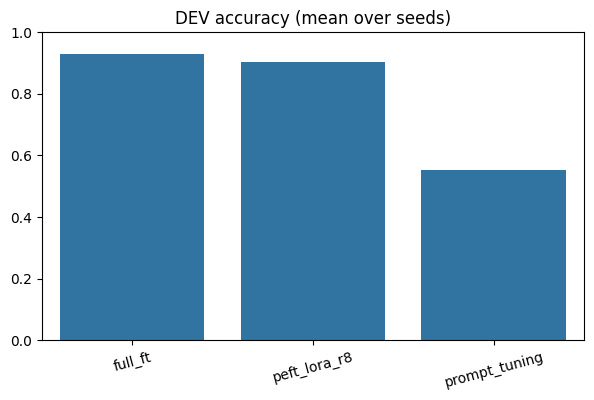

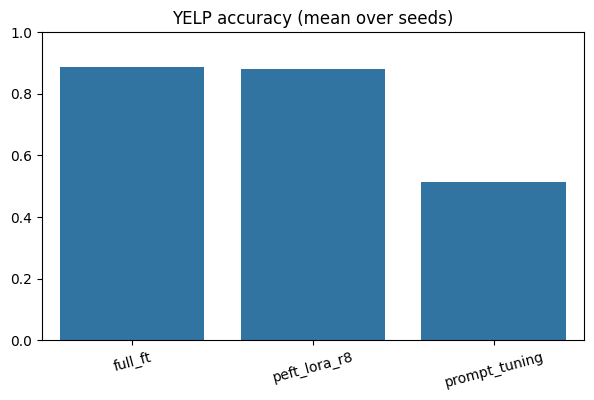

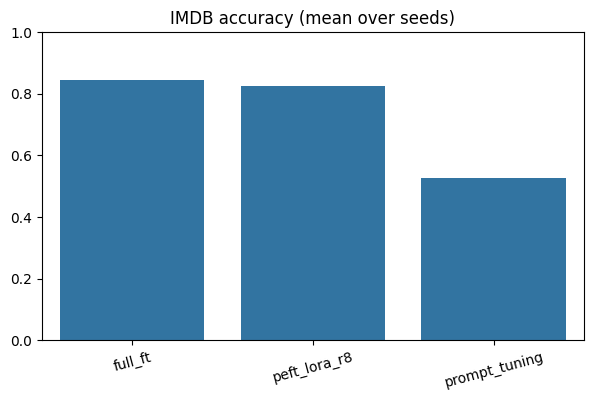

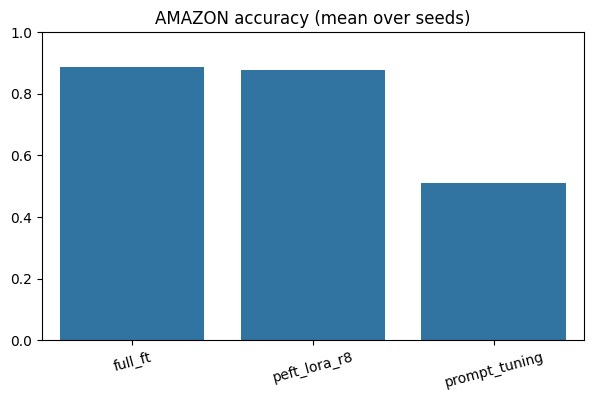

In [ ]:
# Plotting from baseline_means (built from the selected registry file)
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bar_from_baseline_means(split: str, metric: str = 'accuracy'):
    if 'baseline_means' not in globals() or not baseline_means:
        print('Run the registry view builder cell first to populate baseline_means.')
        return
    names, vals = [], []
    for model_name, splits in baseline_means.items():
        if split in splits and metric in splits[split]:
            names.append(model_name)
            vals.append(splits[split][metric])
    if not names:
        print(f'No data to plot for split={split}, metric={metric}')
        return
    plt.figure(figsize=(7,4))
    sns.barplot(x=names, y=vals)
    plt.title(f'{split.upper()} {metric} (mean over seeds)')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=15)
    plt.show()

plot_bar_from_baseline_means('dev', 'accuracy')
plot_bar_from_baseline_means('yelp', 'accuracy')
plot_bar_from_baseline_means('imdb', 'accuracy')
plot_bar_from_baseline_means('amazon', 'accuracy')

Ablation comparison (mean over seeds from results_registry_full.json):


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,combined,r16_lr2e-05,0.9006,0.9005,0.8784,0.8226,0.8765,0.0151,640.27,1771.22,2680322.0
1,learning_rate,r8_lr2e-05,0.8972,0.8971,0.8749,0.8135,0.8711,0.0188,665.95,1751.12,1340930.0
2,lora_rank,r16_lr3e-05,0.9052,0.9051,0.8796,0.8266,0.8788,0.0204,572.71,1771.22,2680322.0


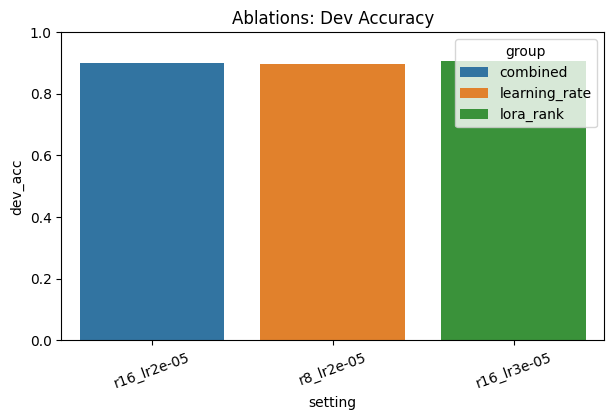

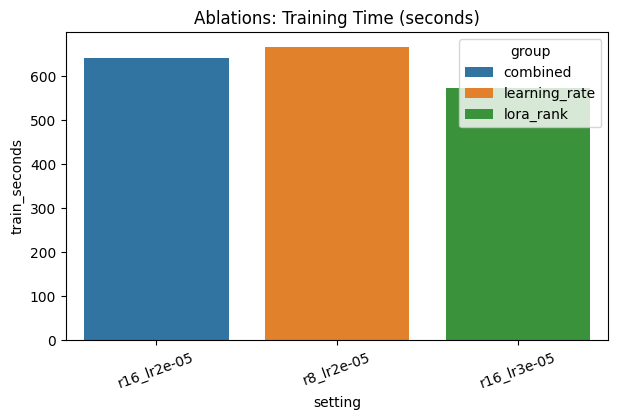

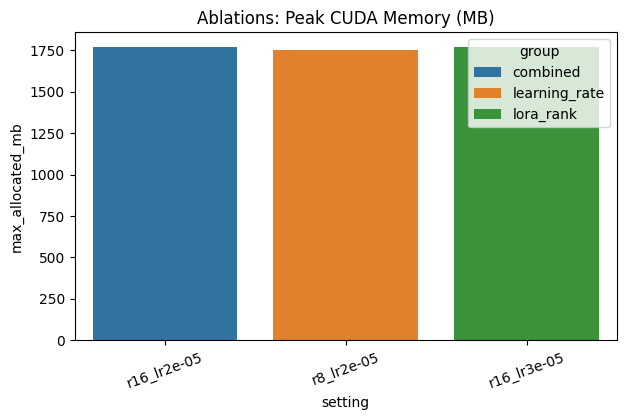

In [ ]:
# Ablation comparison table (performance vs cost) from the selected registry file

import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DEFAULT_LORA_R = globals().get('BASELINE_LORA_R', 8)
DEFAULT_LR = float(globals().get('BASELINE_LR', globals().get('LEARNING_RATE', 3e-5)))

def classify_lora_ablation(lora_r, lr):
    rank_changed = lora_r is not None and int(lora_r) != int(DEFAULT_LORA_R)
    lr_changed = pd.notna(lr) and float(lr) != float(DEFAULT_LR)
    if rank_changed and not lr_changed:
        return 'lora_rank'
    if lr_changed and not rank_changed:
        return 'learning_rate'
    return 'combined'

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    rows = []
    for e in entries:
        if e.get('type') != 'ablation' or e.get('mode') != 'lora':
            continue
        metrics = e.get('result', {}) or {}
        lora_r = e.get('lora_r')
        lr = float(e.get('lr', np.nan))
        rows.append({
            'group': classify_lora_ablation(lora_r, lr),
            'setting': f"r{lora_r if lora_r is not None else 'n/a'}_lr{str(lr).replace('.', 'p') if pd.notna(lr) else 'n/a'}",
            'seed': e.get('seed'),
            'lora_r': lora_r,
            'lr': lr,
            'dev_acc': metrics.get('dev', {}).get('accuracy', np.nan),
            'dev_f1': metrics.get('dev', {}).get('f1_macro', np.nan),
            'yelp_acc': metrics.get('yelp', {}).get('accuracy', np.nan),
            'imdb_acc': metrics.get('imdb', {}).get('accuracy', np.nan),
            'amazon_acc': metrics.get('amazon', {}).get('accuracy', np.nan),
            'ece_dev': metrics.get('ece_dev', np.nan),
            'train_seconds': metrics.get('train_seconds', np.nan),
            'max_allocated_mb': (metrics.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
            'trainable_params': (metrics.get('params') or {}).get('trainable', np.nan),
            'total_params': (metrics.get('params') or {}).get('total', np.nan),
        })

    ablation_df = pd.DataFrame(rows)

    # Development fallback: use LoRA baseline as placeholder when ablations are missing
    if ablation_df.empty and DEVELOPMENT:
        print(f"No ablation rows found in {REGISTRY_FILENAME}.")
        print('DEVELOPMENT=True, so using LoRA baseline as a placeholder ablation row.')

        dev_rows = []

        for e in entries:
            if e.get('type') == 'baseline' and e.get('mode') == 'lora':
                metrics = e.get('result', {}) or {}
                lora_r = e.get('lora_r', DEFAULT_LORA_R)
                lr = float(e.get('lr', DEFAULT_LR))

                dev_rows.append({
                    'group': 'development_placeholder',
                    'setting': f"baseline_r{lora_r}_lr{str(lr).replace('.', 'p')}",
                    'seed': e.get('seed'),
                    'lora_r': lora_r,
                    'lr': lr,
                    'dev_acc': metrics.get('dev', {}).get('accuracy', np.nan),
                    'dev_f1': metrics.get('dev', {}).get('f1_macro', np.nan),
                    'yelp_acc': metrics.get('yelp', {}).get('accuracy', np.nan),
                    'imdb_acc': metrics.get('imdb', {}).get('accuracy', np.nan),
                    'amazon_acc': metrics.get('amazon', {}).get('accuracy', np.nan),
                    'ece_dev': metrics.get('ece_dev', np.nan),
                    'train_seconds': metrics.get('train_seconds', np.nan),
                    'max_allocated_mb': (metrics.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
                    'trainable_params': (metrics.get('params') or {}).get('trainable', np.nan),
                    'total_params': (metrics.get('params') or {}).get('total', np.nan),
                })

        ablation_df = pd.DataFrame(dev_rows)

    if ablation_df.empty:
        print('No ablation rows found and no LoRA baseline placeholder available.')
    else:
        metric_cols = ['dev_acc', 'dev_f1', 'yelp_acc', 'imdb_acc', 'amazon_acc', 'ece_dev']
        mean_cols = metric_cols + ['train_seconds', 'max_allocated_mb', 'trainable_params', 'total_params']
        summary_df = (
            ablation_df
            .groupby(['group', 'setting', 'lora_r', 'lr'], dropna=False)[mean_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

        display_cols = [
            'group', 'setting', 'dev_acc', 'dev_f1', 'yelp_acc', 'imdb_acc', 'amazon_acc',
            'ece_dev', 'train_seconds', 'max_allocated_mb', 'trainable_params'
        ]
        display_df = summary_df[display_cols].copy()
        for c in metric_cols:
            display_df[c] = display_df[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        display_df['train_seconds'] = display_df['train_seconds'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)
        display_df['max_allocated_mb'] = display_df['max_allocated_mb'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)

        print(f"Ablation comparison (mean over seeds from {REGISTRY_FILENAME}):")
        display(display_df.sort_values(['group', 'setting']).reset_index(drop=True))

        for y_col, title in [
            ('dev_acc', 'Ablations: Dev Accuracy'),
            ('train_seconds', 'Ablations: Training Time (seconds)'),
            ('max_allocated_mb', 'Ablations: Peak CUDA Memory (MB)'),
        ]:
            plot_df = display_df.dropna(subset=[y_col])
            if plot_df.empty:
                print(f'No {y_col} values available to plot.')
                continue
            plt.figure(figsize=(7,4))
            sns.barplot(data=plot_df, x='setting', y=y_col, hue='group')
            plt.title(title)
            if y_col == 'dev_acc':
                plt.ylim(0, 1.0)
            plt.xticks(rotation=20)
            plt.show()

## Final multi-seed results analysis

These cells analyze the completed experiment grid from `outputs/results_registry_full.json`. They aggregate each method/configuration across seeds `7`, `42`, and `2026`, then compute cross-domain generalization, robustness drops, calibration metrics, and computational efficiency for the final report.

In [ ]:
# Final results analysis from the full multi-seed registry
import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FULL_REGISTRY_PATH = os.path.join('outputs', 'results_registry_full.json')
PLANNED_SEEDS = [7, 42, 2026]
DOMAINS = ['yelp', 'imdb', 'amazon']
ROBUST_SPLITS = {
    'punctuation': 'robust_dev_punctuation',
    'char_noise': 'robust_dev_char_noise',
    'synonym': 'robust_dev_synonym',
}


def _nested(metrics, *keys, default=np.nan):
    cur = metrics
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def _method_label(entry):
    if entry.get('type') == 'baseline':
        return {
            'full': 'full_ft',
            'lora': f"peft_lora_r{entry.get('lora_r', globals().get('BASELINE_LORA_R', 8))}",
            'prompt': 'prompt_tuning',
        }.get(entry.get('mode'), entry.get('mode', 'unknown'))
    if entry.get('mode') == 'lora':
        lr = entry.get('lr', np.nan)
        lr_label = 'na' if pd.isna(lr) else f"{float(lr):.0e}"
        return f"lora_r{entry.get('lora_r', 'na')}_lr{lr_label}"
    return f"{entry.get('mode', 'unknown')}_{entry.get('type', 'run')}"


def flatten_registry(registry):
    rows = []
    entries = registry.items() if isinstance(registry, dict) else enumerate(registry)

    for run_key, entry in entries:
        metrics = entry.get('result', {}) or {}
        yelp_acc = _nested(metrics, 'yelp', 'accuracy')
        imdb_acc = _nested(metrics, 'imdb', 'accuracy')
        amazon_acc = _nested(metrics, 'amazon', 'accuracy')
        yelp_f1 = _nested(metrics, 'yelp', 'f1_macro')
        imdb_f1 = _nested(metrics, 'imdb', 'f1_macro')
        amazon_f1 = _nested(metrics, 'amazon', 'f1_macro')
        cross_acc = np.nanmean([yelp_acc, imdb_acc, amazon_acc])
        cross_f1 = np.nanmean([yelp_f1, imdb_f1, amazon_f1])
        dev_acc = _nested(metrics, 'dev', 'accuracy')
        dev_f1 = _nested(metrics, 'dev', 'f1_macro')

        row = {
            'run_key': run_key,
            'run_type': entry.get('type'),
            'mode': entry.get('mode'),
            'method': _method_label(entry),
            'seed': entry.get('seed'),
            'lora_r': entry.get('lora_r'),
            'lr': entry.get('lr'),
            'dev_accuracy': dev_acc,
            'dev_f1_macro': dev_f1,
            'yelp_accuracy': yelp_acc,
            'yelp_f1_macro': yelp_f1,
            'imdb_accuracy': imdb_acc,
            'imdb_f1_macro': imdb_f1,
            'amazon_accuracy': amazon_acc,
            'amazon_f1_macro': amazon_f1,
            'cross_domain_avg_accuracy': cross_acc,
            'cross_domain_avg_f1': cross_f1,
            'generalization_gap': dev_acc - cross_acc,
            'ece_dev': metrics.get('ece_dev', np.nan),
            'temp': metrics.get('temp', np.nan),
            'params_total': _nested(metrics, 'params', 'total'),
            'params_trainable': _nested(metrics, 'params', 'trainable'),
            'train_seconds': metrics.get('train_seconds', np.nan),
            'cuda_max_allocated_mb': _nested(metrics, 'cuda_mem', 'max_allocated_mb'),
            'cuda_reserved_mb': _nested(metrics, 'cuda_mem', 'reserved_mb'),
        }

        for label, split in ROBUST_SPLITS.items():
            robust_acc = _nested(metrics, split, 'accuracy')
            robust_f1 = _nested(metrics, split, 'f1_macro')
            row[f'robust_{label}_accuracy'] = robust_acc
            row[f'robust_{label}_f1_macro'] = robust_f1
            row[f'{label}_accuracy_drop'] = dev_acc - robust_acc
            row[f'{label}_f1_drop'] = dev_f1 - robust_f1

        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df[df['seed'].isin(PLANNED_SEEDS)].copy()
        df['params_trainable_pct'] = 100 * df['params_trainable'] / df['params_total']
    return df


def summarize_mean_std(df, group_cols, metric_cols):
    summary = df.groupby(group_cols, dropna=False)[metric_cols].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = ['_'.join([str(part) for part in col if part]) for col in summary.columns.to_flat_index()]
    return summary


def fmt_mean_std(summary, group_cols, metric_cols, decimals=4):
    rows = []
    for _, row in summary.iterrows():
        out = {col: row[col] for col in group_cols}
        seed_count = int(max([row.get(f'{metric}_count', 0) for metric in metric_cols] or [0]))
        out['n_seeds'] = seed_count
        for metric in metric_cols:
            mean = row.get(f'{metric}_mean', np.nan)
            std = row.get(f'{metric}_std', np.nan)
            if pd.isna(mean):
                out[metric] = np.nan
            else:
                std = 0.0 if pd.isna(std) else std
                out[metric] = f"{mean:.{decimals}f} +/- {std:.{decimals}f}"
        rows.append(out)
    return pd.DataFrame(rows)

if not os.path.exists(FULL_REGISTRY_PATH):
    print(f"Full registry not found: {FULL_REGISTRY_PATH}")
    print('Run the full experiment grid first, then re-run this analysis cell.')
else:
    with open(FULL_REGISTRY_PATH, 'r') as f:
        full_registry = json.load(f)

    final_runs_df = flatten_registry(full_registry)
    if final_runs_df.empty:
        print(f'No runs for planned seeds {PLANNED_SEEDS} found in {FULL_REGISTRY_PATH}.')
    else:
        present = sorted(final_runs_df['seed'].dropna().astype(int).unique().tolist())
        missing = sorted(set(PLANNED_SEEDS) - set(present))
        print(f'Loaded {len(final_runs_df)} runs from {FULL_REGISTRY_PATH}. Seeds present: {present}')
        if missing:
            print(f'Warning: planned seeds missing from registry: {missing}')

        display(final_runs_df[['run_key', 'run_type', 'method', 'seed', 'dev_accuracy', 'cross_domain_avg_accuracy', 'generalization_gap', 'ece_dev', 'params_trainable', 'train_seconds']])


In [ ]:
# Final report tables: generalization, robustness, calibration, efficiency, and ablations
def barplot_with_sd(*args, **kwargs):
    try:
        return sns.barplot(*args, errorbar='sd', **kwargs)
    except TypeError:
        return sns.barplot(*args, ci='sd', **kwargs)

if 'final_runs_df' not in globals() or final_runs_df.empty:
    print('Run the final registry loading cell first.')
else:
    baseline_df = final_runs_df[final_runs_df['run_type'].eq('baseline')].copy()
    ablation_df = final_runs_df[final_runs_df['run_type'].eq('ablation')].copy()

    baseline_group_cols = ['run_type', 'method', 'mode']
    baseline_metrics = [
        'dev_accuracy', 'dev_f1_macro',
        'yelp_accuracy', 'yelp_f1_macro', 'imdb_accuracy', 'imdb_f1_macro', 'amazon_accuracy', 'amazon_f1_macro',
        'cross_domain_avg_accuracy', 'cross_domain_avg_f1', 'generalization_gap',
        'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop',
        'ece_dev', 'temp', 'params_trainable', 'params_trainable_pct',
        'train_seconds', 'cuda_max_allocated_mb', 'cuda_reserved_mb',
    ]

    if baseline_df.empty:
        print('No baseline rows found in the full registry.')
    else:
        baseline_summary = summarize_mean_std(baseline_df, baseline_group_cols, baseline_metrics)

        print('Cross-domain generalization (mean +/- std over seeds)')
        display(fmt_mean_std(
            baseline_summary,
            baseline_group_cols,
            ['dev_accuracy', 'dev_f1_macro', 'cross_domain_avg_accuracy', 'cross_domain_avg_f1', 'generalization_gap']
        ).sort_values('method').reset_index(drop=True))

        print('Per-domain accuracy/F1 (mean +/- std over seeds)')
        display(fmt_mean_std(
            baseline_summary,
            baseline_group_cols,
            ['yelp_accuracy', 'yelp_f1_macro', 'imdb_accuracy', 'imdb_f1_macro', 'amazon_accuracy', 'amazon_f1_macro']
        ).sort_values('method').reset_index(drop=True))

        print('Robustness drops vs clean SST-2 dev accuracy (lower is better)')
        display(fmt_mean_std(
            baseline_summary,
            baseline_group_cols,
            ['punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop']
        ).sort_values('method').reset_index(drop=True))

        print('Calibration after temperature scaling (lower ECE is better)')
        display(fmt_mean_std(
            baseline_summary,
            baseline_group_cols,
            ['ece_dev', 'temp']
        ).sort_values('method').reset_index(drop=True))

        efficiency = baseline_summary[[
            'run_type', 'method', 'mode',
            'params_trainable_mean', 'params_trainable_std', 'params_trainable_pct_mean',
            'train_seconds_mean', 'train_seconds_std',
            'cuda_max_allocated_mb_mean', 'cuda_max_allocated_mb_std',
        ]].copy()
        full_trainable = efficiency.loc[efficiency['mode'].eq('full'), 'params_trainable_mean']
        full_time = efficiency.loc[efficiency['mode'].eq('full'), 'train_seconds_mean']
        full_mem = efficiency.loc[efficiency['mode'].eq('full'), 'cuda_max_allocated_mb_mean']
        if not full_trainable.empty:
            efficiency['trainable_param_reduction_vs_full'] = full_trainable.iloc[0] / efficiency['params_trainable_mean']
        if not full_time.empty:
            efficiency['training_time_saved_vs_full_sec'] = full_time.iloc[0] - efficiency['train_seconds_mean']
        if not full_mem.empty:
            efficiency['cuda_memory_saved_vs_full_mb'] = full_mem.iloc[0] - efficiency['cuda_max_allocated_mb_mean']

        for col in efficiency.select_dtypes(include='number').columns:
            efficiency[col] = efficiency[col].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        print('Computational efficiency (means over seeds, plus reduction relative to full fine-tuning)')
        display(efficiency.sort_values('method').reset_index(drop=True))

    if ablation_df.empty:
        print('No LoRA ablation rows found in the full registry.')
    else:
        ablation_group_cols = ['run_type', 'method', 'mode', 'lora_r', 'lr']
        ablation_metrics = [
            'dev_accuracy', 'dev_f1_macro', 'cross_domain_avg_accuracy', 'cross_domain_avg_f1',
            'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop',
            'ece_dev', 'params_trainable', 'train_seconds', 'cuda_max_allocated_mb',
        ]
        ablation_summary = summarize_mean_std(ablation_df, ablation_group_cols, ablation_metrics)
        print('LoRA ablation analysis (mean +/- std over seeds)')
        display(fmt_mean_std(ablation_summary, ablation_group_cols, ablation_metrics).sort_values(['lora_r', 'lr']).reset_index(drop=True))

    if not baseline_df.empty:
        plot_df = baseline_df.melt(
            id_vars=['method', 'seed'],
            value_vars=['dev_accuracy', 'cross_domain_avg_accuracy'],
            var_name='metric',
            value_name='score',
        )
        plt.figure(figsize=(7, 4))
        barplot_with_sd(data=plot_df, x='method', y='score', hue='metric')
        plt.ylim(0, 1.0)
        plt.title('Clean SST-2 vs cross-domain average accuracy')
        plt.xticks(rotation=15)
        plt.show()

        robust_plot_df = baseline_df.melt(
            id_vars=['method', 'seed'],
            value_vars=['punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop'],
            var_name='perturbation',
            value_name='accuracy_drop',
        )
        plt.figure(figsize=(8, 4))
        barplot_with_sd(data=robust_plot_df, x='method', y='accuracy_drop', hue='perturbation')
        plt.title('Robustness: accuracy drop under perturbation')
        plt.xticks(rotation=15)
        plt.show()


In [ ]:
# Auto-generated interpretation helper for the final discussion
if 'baseline_df' not in globals() or baseline_df.empty:
    print('Run the final report tables cell first.')
else:
    baseline_mean = baseline_df.groupby(['method', 'mode'], dropna=False).mean(numeric_only=True).reset_index()

    best_dev = baseline_mean.loc[baseline_mean['dev_accuracy'].idxmax()]
    best_cross = baseline_mean.loc[baseline_mean['cross_domain_avg_accuracy'].idxmax()]
    best_gap = baseline_mean.loc[baseline_mean['generalization_gap'].idxmin()]
    best_robust = baseline_mean.assign(avg_robust_drop=lambda d: d[[
        'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop'
    ]].mean(axis=1)).loc[lambda d: d['avg_robust_drop'].idxmin()]
    best_cal = baseline_mean.loc[baseline_mean['ece_dev'].idxmin()]
    fewest_params = baseline_mean.loc[baseline_mean['params_trainable'].idxmin()]

    print('Final conclusion notes to use in the report:')
    print(f"- Strongest in-domain SST-2 dev accuracy: {best_dev['method']} ({best_dev['dev_accuracy']:.4f}).")
    print(f"- Strongest average cross-domain accuracy: {best_cross['method']} ({best_cross['cross_domain_avg_accuracy']:.4f}).")
    print(f"- Smallest generalization gap: {best_gap['method']} ({best_gap['generalization_gap']:.4f}).")
    print(f"- Smallest average robustness drop: {best_robust['method']} ({best_robust['avg_robust_drop']:.4f}).")
    print(f"- Best calibration / lowest ECE: {best_cal['method']} ({best_cal['ece_dev']:.4f}, temp={best_cal['temp']:.2f}).")
    print(f"- Fewest trainable parameters: {fewest_params['method']} ({fewest_params['params_trainable']:.0f}).")

    lora_rows = baseline_mean[baseline_mean['mode'].eq('lora')]
    full_rows = baseline_mean[baseline_mean['mode'].eq('full')]
    prompt_rows = baseline_mean[baseline_mean['mode'].eq('prompt')]
    if not lora_rows.empty and not full_rows.empty:
        lora = lora_rows.iloc[0]
        full = full_rows.iloc[0]
        print(
            f"- LoRA uses about {full['params_trainable'] / lora['params_trainable']:.1f}x fewer trainable "
            f"parameters than full fine-tuning while reaching "
            f"{lora['cross_domain_avg_accuracy'] / full['cross_domain_avg_accuracy']:.1%} of its cross-domain accuracy."
        )
    if not prompt_rows.empty:
        prompt = prompt_rows.iloc[0]
        print(
            f"- Prompt-tuning trains only {prompt['params_trainable_pct']:.4f}% of parameters; compare this with "
            'its accuracy before calling it the best option overall.'
        )
